In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import json
from utils.dct import dct_based_compression, snr

In [2]:
config = "./config/config.json"
config = json.load(open(config))

In [3]:
# normalize radar signal
def normalize(radar_FFT, config):
    for i in range(len(config['dataset']['statistics']['input_mean'])):
        radar_FFT[...,i] -= config['dataset']['statistics']['input_mean'][i]
        radar_FFT[...,i] /= config['dataset']['statistics']['input_std'][i]
    return radar_FFT

# de-normalize radar signal
def denormalize(radar_FFT, config):
    for k in range(len(config['dataset']['statistics']['input_mean'])):
        radar_FFT[..., k] *= config['dataset']['statistics']['input_std'][k]
        radar_FFT[..., k] += config['dataset']['statistics']['input_mean'][k]
    return radar_FFT

The range-Doppler map visualizes the log-power spectrum $\log\|\mathcal{X}_c\| = \log\!\left\lVert \mathbf{x}_{2c} + j\mathbf{x}_{2c+1} \right\rVert$.

The radar’s complex feature tensor $\mathcal{X}\in\mathbb{C}^{C\times H\times W}$ is decomposed into its real and imaginary parts and concatenated along the channel dimension to form the real-valued tensor $\mathbf{x}\in\mathbb{R}^{2C\times H\times W}$.

In [4]:
# compression related args
comp_ratio = 1              # compression ratio
BL = 64                     # block length
quantize = False             # apply quantization
qbit = 16                    # quant bit width

# load raw radar 
radar_name = os.path.join("./data/fft_000018.npy")
data = np.load(radar_name,allow_pickle=True)
radar_FFT_ref = np.concatenate([data.real, data.imag],axis=2)
radar_FFT_ref = normalize(radar_FFT_ref, config)    # normalize radar signal

# reshape radar_FFT s.t. input ~ [N, C, H, W]
radar_FFT = np.expand_dims(radar_FFT_ref, axis=0)   # unsqueeze
radar_FFT = np.transpose(radar_FFT, (0,3,1,2))      # change order

# spectral compression
radar_FFT_comp, _ = dct_based_compression(radar_FFT, comp_ratio, BL, quantize, qbit)  # radar_FFT input ~ [N, C, H, W]
radar_FFT_comp = np.transpose(radar_FFT_comp[0], (1, 2, 0))

radar_FFT_ref = denormalize(radar_FFT_ref, config)      # de-normalize radar signal
radar_FFT_RI = radar_FFT_ref[...,::2]+1j*radar_FFT_ref[...,1::2]
power_spectrum_ref =  10*np.log10(np.sum(np.abs(radar_FFT_RI),axis=2))

radar_FFT_comp = denormalize(radar_FFT_comp, config)    # de-normalize radar signal
radar_FFT_comp = radar_FFT_comp[...,::2]+1j*radar_FFT_comp[...,1::2]
power_spectrum_comp = 10*np.log10(np.sum(np.abs(radar_FFT_comp),axis=2))

snr_val = snr(power_spectrum_ref,power_spectrum_comp)

print(f"SNR of Range Doppler Map: {snr_val:.2f} dB")

SNR of Range Doppler Map: 147.70 dB


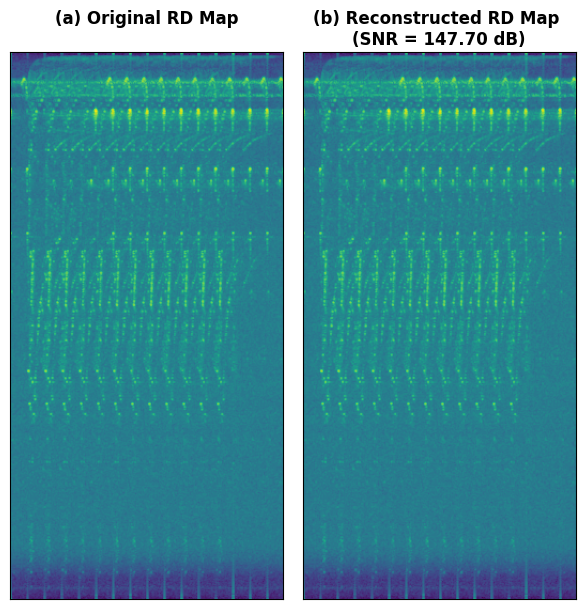

In [5]:
# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 6))

ax1.imshow(np.log10(power_spectrum_ref))
ax1.set_title("(a) Original RD Map\n", fontweight='bold')

ax2.imshow(np.log10(power_spectrum_comp))
ax2.set_title(f"(b) Reconstructed RD Map \n(SNR = {snr_val:.2f} dB)", fontweight='bold')
for ax in [ax1, ax2]: ax.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)

plt.tight_layout()
plt.show()

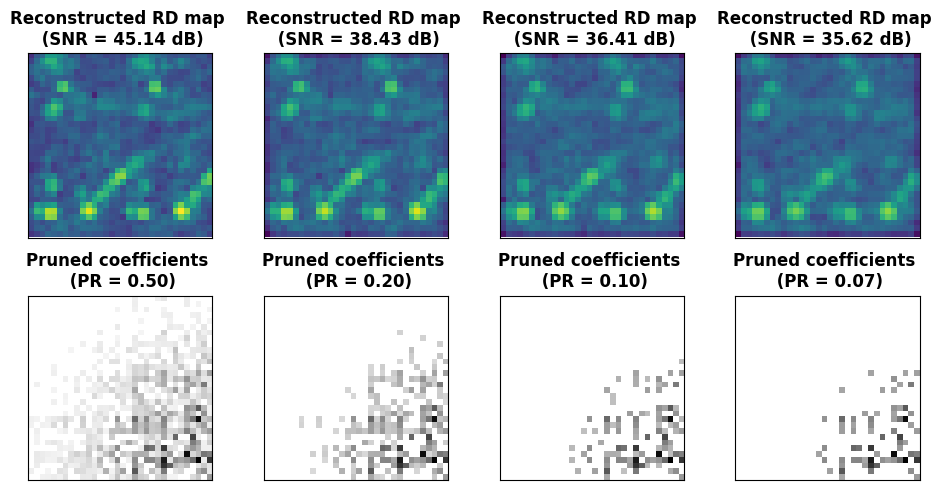

In [7]:
# compression related args
BL = 32                     # block length
quantize = False             # apply quantization
qbit = 8                    # quant bit width

cr_arr = [2,5,10,15]        # compression ratio array for sweep

# visualization
y = 2                       # patch loc vertical
x = 1                       # patch loc horizontal
ch = 0                      # channel

imgs = []
coef = []
snr_arr = []
nz_arr = []

# load raw radar 
radar_name = os.path.join("./data/fft_000018.npy")
data = np.load(radar_name,allow_pickle=True)
radar_FFT_tmp = np.concatenate([data.real, data.imag],axis=2)
radar_FFT_tmp = denormalize(radar_FFT_tmp, config)      # de-normalize radar signal

radar_FFT_ref = radar_FFT_tmp.copy()
radar_FFT_RI = radar_FFT_tmp.copy()

radar_FFT_RI = denormalize(radar_FFT_RI, config)        # normalize radar signal
radar_FFT_RI = radar_FFT_RI[...,::2]+1j*radar_FFT_RI[...,1::2]
power_spectrum_ref =  10*np.log10(np.sum(np.abs(radar_FFT_RI),axis=2))

for i, comp_ratio in enumerate(cr_arr):  
    radar_FFT = np.expand_dims(radar_FFT_ref, axis=0)   # unsqueeze
    radar_FFT = np.transpose(radar_FFT, (0,3,1,2))      # change order
    
    radar_FFT_comp, dct_coef = dct_based_compression(radar_FFT, comp_ratio, BL, quantize, qbit)
    radar_FFT_comp = np.transpose(radar_FFT_comp[0], (1, 2, 0))

    radar_FFT_comp = denormalize(radar_FFT_comp, config) # normalize radar signal
    radar_FFT_comp = radar_FFT_comp[...,::2]+1j*radar_FFT_comp[...,1::2]
    power_spectrum_comp = 10*np.log10(np.sum(np.abs(radar_FFT_comp),axis=2))

    snr_arr.append(snr(power_spectrum_ref, power_spectrum_comp))
    nz_arr.append(np.count_nonzero(dct_coef))

    piece_rd = power_spectrum_comp[BL*y:BL*(y+1), BL*x:BL*(x+1)]
    imgs.append(piece_rd)

    piece_dct = dct_coef[0,ch,BL*y:BL*(y+1),BL*x:BL*(x+1)]
    coef.append(piece_dct)

# Compute global min and max
vmin = min(img.min() for img in imgs)
vmax = max(img.max() for img in imgs)

fig, axes = plt.subplots(2, 4, figsize=(10, 5), tight_layout=True)  # 2 row, 4 columns
axes = axes.flatten()

off = 4
for i, comp_ratio in enumerate(cr_arr):
    # RD map
    axes[i].imshow(imgs[i], vmin=vmin, vmax=vmax)
    # axes[i].axis('off')  # optional
    axes[i].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axes[i].set_title(f"Reconstructed RD map \n (SNR = {snr_arr[i]:.2f} dB)", fontweight = 'bold')

    # dct coeff
    axes[i+off].imshow(np.abs(coef[i]), cmap = 'binary')
    # axes[i+off].axis('off')  # optional
    axes[i+off].tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
    axes[i+off].set_title(f"Pruned coefficients \n (PR = {1/comp_ratio:.2f})", fontweight = 'bold',)
